In [9]:
!pip install scipy
!pip install scikit-learn
!pip install factor-analyzer

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for factor-analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42783 sha256=be51bfb87a0f1cf00f6d7960d9e7d05e196d701a9bf2317871a11a9c41b6a6d8
  Stored in directory: c:\users\aguer\appdata\local\pip\cache\wheels\f4\75\34\af21a56ae40d82b2eec282b05d3e44315ef5ebbc853a8cd947
Successfully built factor-analyzer


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer, calculate_kmo, calculate_bartlett_sphericity

ruta_figuras = "../figures"

In [11]:
df = pd.read_parquet("../data/processed/songs.parquet")

df.shape

(81198, 24)

In [12]:
# Variables de audio features para el análisis
AUDIO_FEATURES = [
    "danceability", "energy", "loudness",
    "acousticness", "instrumentalness",
    "speechiness", "liveness", "valence", 
    "tempo"
]

X = df[AUDIO_FEATURES].copy()

print(f"Shape de la matriz de datos: {X.shape}")

Shape de la matriz de datos: (81198, 9)


In [13]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=AUDIO_FEATURES,
    index=df.index
)

X_scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,81198.0,5.600475e-17,1.000006,-2.886851,-0.642514,0.077807,0.735737,2.408922
energy,81198.0,-1.736147e-16,1.000006,-2.466705,-0.697667,0.163613,0.858069,1.412858
loudness,81198.0,-9.520807e-17,1.000006,-7.225632,-0.353633,0.249808,0.652735,2.490805
acousticness,81198.0,1.729147e-16,1.000006,-0.969464,-0.922659,-0.410154,0.879203,1.962498
instrumentalness,81198.0,1.120095e-17,1.000006,-0.555754,-0.555754,-0.555492,-0.105463,2.466330
speechiness,81198.0,0.000000e+00,1.000006,-0.574716,-0.454714,-0.342426,-0.016706,7.507429
liveness,81198.0,8.400712e-17,1.000006,-1.062495,-0.611159,-0.436693,0.316797,3.947711
valence,81198.0,3.010255e-16,1.000006,-1.765349,-0.844873,-0.057524,0.805898,2.019253
tempo,81198.0,-9.555810e-17,1.000006,-3.102551,-0.764554,-0.010383,0.598893,4.074363


# Matriz de correlaciones

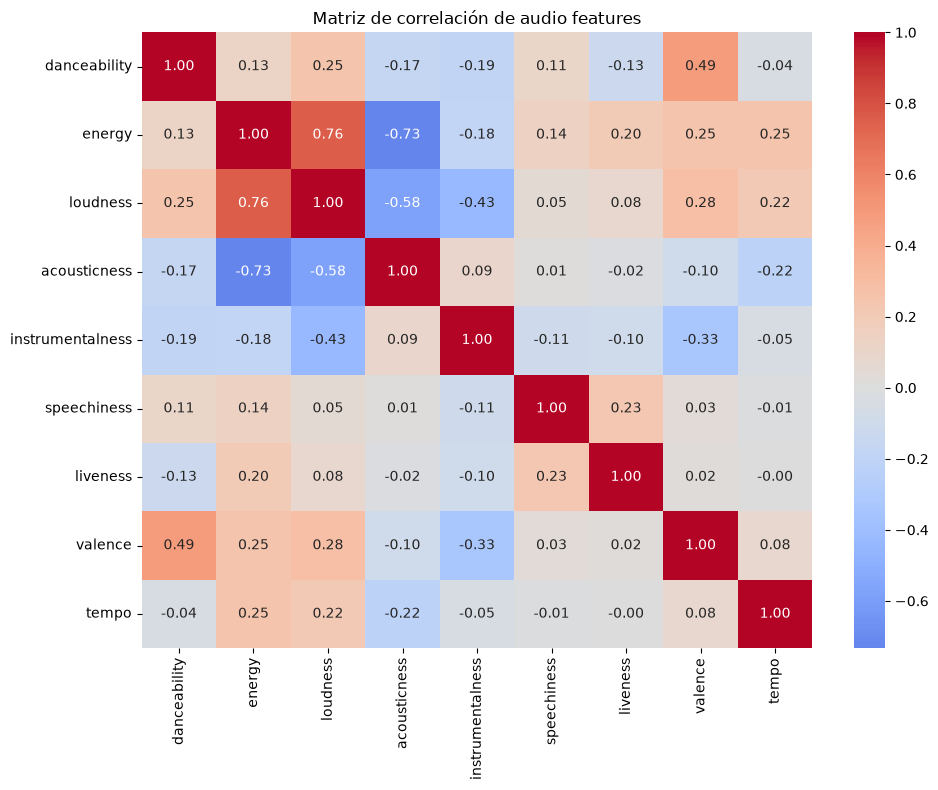

In [14]:
corr = X.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de correlación de audio features")
plt.tight_layout()
plt.savefig(f"{ruta_figuras}/corrplot_X.png", dpi=300)
plt.show()

# Test Barlett y KMO

In [15]:
def evaluar_kmo_bartlett(X, nombre_modelo):
    
    chi2, p_value = calculate_bartlett_sphericity(X)
    kmo_all, kmo_model = calculate_kmo(X)
    
    kmo_df = pd.DataFrame({
        "modelo": nombre_modelo,
        "variable": X.columns,
        "KMO_individual": kmo_all
    }).sort_values("KMO_individual")
    
    resumen = {
        "modelo": nombre_modelo,
        "n_variables": X.shape[1],
        "chi2_bartlett": chi2,
        "p_value_bartlett": p_value,
        "KMO_global": kmo_model
    }
    
    return resumen, kmo_df

In [16]:
modelos = {
    "AFE_1": [
        "danceability", "energy", "loudness",
        "speechiness", "acousticness", "instrumentalness",
        "liveness", "valence", "tempo"
    ],
    "AFE_2": [
        "danceability", "energy", "loudness",
        "acousticness", "instrumentalness",
        "liveness", "valence", "tempo"
    ],
    "AFE_3": [
        "danceability", "energy", "loudness",
        "acousticness", "instrumentalness",
        "valence", "tempo"
    ],
    "AFE_4": [
        "energy", "loudness",
        "acousticness", "instrumentalness",
        "valence", "tempo"
    ]
}

resumenes = []
kmos = []

for nombre, features in modelos.items():
    X = df[features].copy()
    resumen, kmo_df = evaluar_kmo_bartlett(X, nombre)
    resumenes.append(resumen)
    kmos.append(kmo_df)

resumen_modelos = pd.DataFrame(resumenes)
kmo_modelos = pd.concat(kmos, ignore_index=True)

resumen_modelos



,modelo,n_variables,chi2_bartlett,p_value_bartlett,KMO_global
0,AFE_1,9,226152.016171,0.0,0.589900
1,AFE_2,8,215130.384591,0.0,0.616723
2,AFE_3,7,205596.227432,0.0,0.630667
3,AFE_4,6,175931.808442,0.0,0.683661


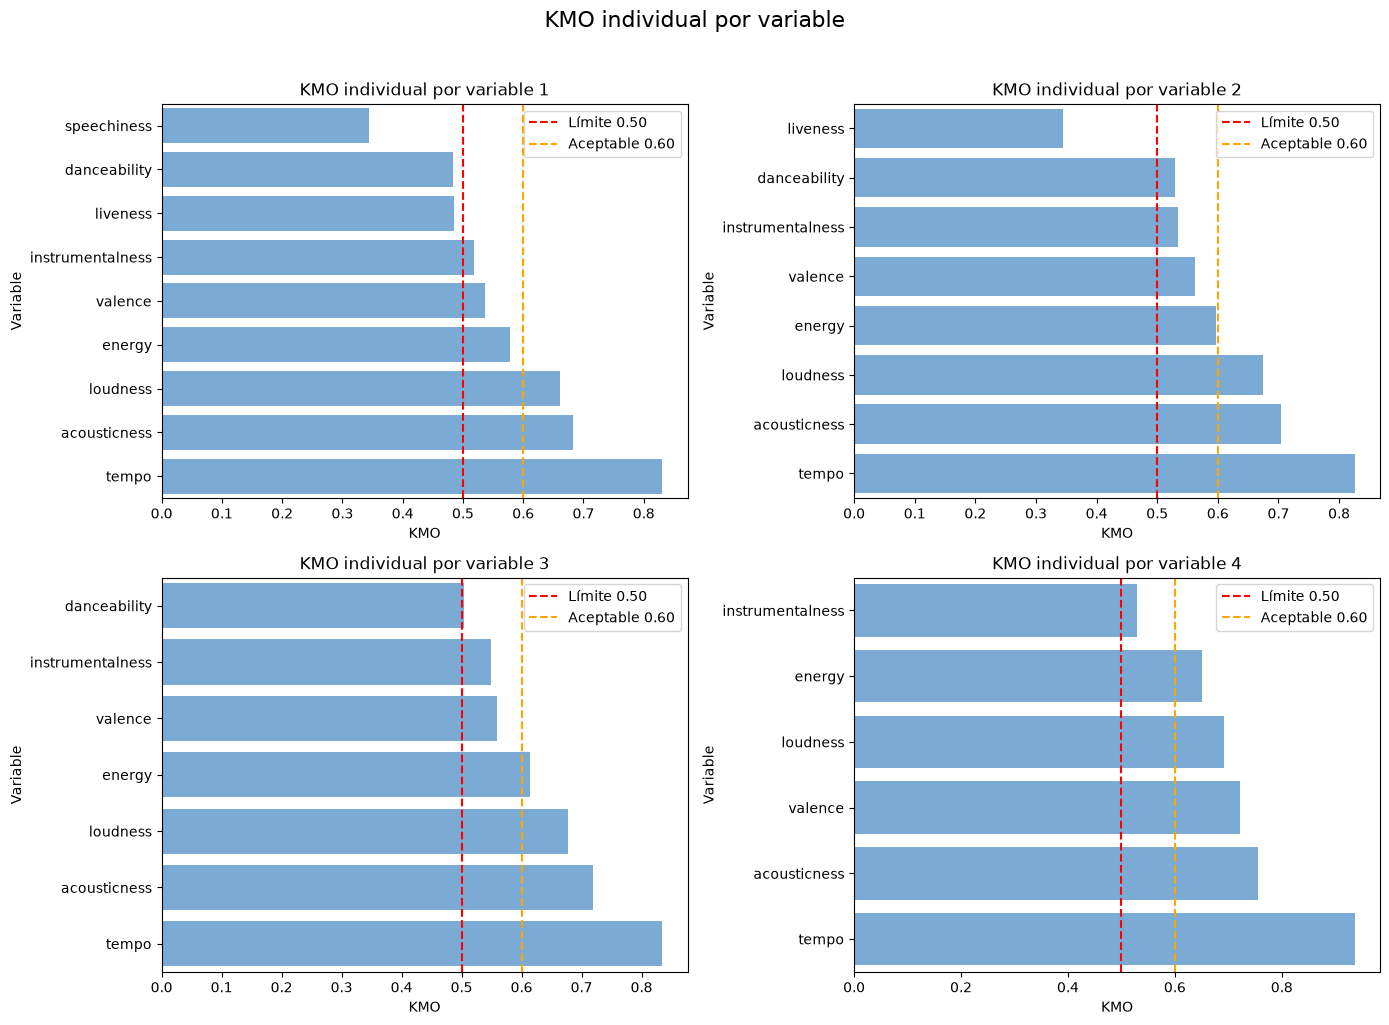

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

for i, kmo in enumerate(kmos):
    sns.barplot(
        data=kmo,
        x="KMO_individual",
        y="variable",
        color="#6CACE4",
        ax=axes[i]
    )

    axes[i].axvline(0.5, color="red", linestyle="--", label="Límite 0.50")
    axes[i].axvline(0.6, color="orange", linestyle="--", label="Aceptable 0.60")

    axes[i].set_title(f"KMO individual por variable {i+1}")
    axes[i].set_xlabel("KMO")
    axes[i].set_ylabel("Variable")
    axes[i].legend()

# Por si hay menos de 4 gráficos, elimina ejes vacíos
for j in range(len(kmos), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("KMO individual por variable", fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

# ESTUDIO CATEGORICAS

In [18]:
desc_key = (
    df
    .groupby("key")[AUDIO_FEATURES]
    .agg(["mean", "std", "count"])
)

desc_mode = (
    df
    .groupby("mode")[AUDIO_FEATURES]
    .agg(["mean", "std", "count"])
)

desc_key_mode = (
    df
    .groupby(["key", "mode"])[AUDIO_FEATURES]
    .agg(["mean", "std", "count"])
)

In [19]:
print(desc_key)
print(desc_mode)
print(desc_key_mode)

      danceability                    energy                  loudness  \
              mean       std count      mean       std count      mean   
key                                                                      
A         0.551339  0.173139  8208  0.635162  0.256147  8208 -8.549627   
A#/Bb     0.576865  0.181257  5290  0.637249  0.256452  5290 -8.748810   
B         0.582763  0.171461  6459  0.677775  0.235573  6459 -7.858548   
C         0.557116  0.178524  9275  0.601109  0.262898  9275 -9.050446   
C#/Db     0.571915  0.186262  7730  0.684950  0.245503  7730 -8.138632   
D         0.541123  0.172905  8560  0.613351  0.263716  8560 -8.848293   
D#/Eb     0.529784  0.180876  2469  0.551739  0.277590  2469 -9.823891   
E         0.549894  0.170510  6576  0.630415  0.255272  6576 -8.551812   
F         0.558194  0.175035  6519  0.608588  0.263595  6519 -8.908736   
F#/Gb     0.574015  0.172882  5524  0.678623  0.245213  5524 -7.951553   
G         0.558098  0.173316  9642  0.

### Diferencias genero / key

In [20]:
from scipy.stats import chi2_contingency
def cramers_v(confusion_matrix):
    chi2, p, dof, expected = chi2_contingency(confusion_matrix)

    n = confusion_matrix.to_numpy().sum()
    r, k = confusion_matrix.shape

    phi2 = chi2 / n

    # Corrección de sesgo
    phi2_corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    v = np.sqrt(
        phi2_corr / min((k_corr - 1), (r_corr - 1))
    )

    return chi2, p, dof, v, expected

In [21]:
tabla_key_genre = pd.crosstab(
    df["key"],
    df["main_genre"]
)

chi2, p, dof, v, expected = cramers_v(tabla_key_genre)

print("main_genre ~ key")
print("chi2:", chi2)
print("p_value:", p)
print("dof:", dof)
print("Cramer's V:", v)

tabla_mode_genre = pd.crosstab(
    df["mode"],
    df["main_genre"]
)

chi2, p, dof, v, expected = cramers_v(tabla_mode_genre)

print("\nmain_genre ~ mode")
print("chi2:", chi2)
print("p_value:", p)
print("dof:", dof)
print("Cramer's V:", v)


tabla_ts_genre = pd.crosstab(
    df["time_signature"],
    df["main_genre"]
)

chi2, p, dof, v, expected = cramers_v(tabla_ts_genre)

print("\nmain_genre ~ time_signature")
print("chi2:", chi2)
print("p_value:", p)
print("dof:", dof)
print("Cramer's V:", v)

main_genre ~ key
chi2: 6859.337094019647
p_value: 0.0
dof: 1232
Cramer's V: 0.07938003592651464

main_genre ~ mode
chi2: 5155.36826733347
p_value: 0.0
dof: 112
Cramer's V: 0.2492242453481233

main_genre ~ time_signature
chi2: 10847.115263998645
p_value: 0.0
dof: 336
Cramer's V: 0.20772991502504468


In [22]:
df["key_mode"] = (
    df["key"].astype(str)
    + "_"
    + df["mode"].astype(str)
)

tabla_keymode_genre = pd.crosstab(
    df["key_mode"],
    df["main_genre"]
)

chi2, p, dof, v, expected = cramers_v(tabla_keymode_genre)

print("main_genre ~ key_mode")
print("chi2:", chi2)
print("p_value:", p)
print("dof:", dof)
print("Cramer's V:", v)


df["key_ts"] = (
    df["key"].astype(str)
    + "_"
    + df["time_signature"].astype(str)
)

tabla_keyts_genre = pd.crosstab(
    df["key_ts"],
    df["main_genre"]
)

chi2, p, dof, v, expected = cramers_v(tabla_keyts_genre)

print("\nmain_genre ~ key_ts")
print("chi2:", chi2)
print("p_value:", p)
print("dof:", dof)
print("Cramer's V:", v)


df["ts_mode"] = (
    df["time_signature"].astype(str)
    + "_"
    + df["mode"].astype(str)
)

tabla_tsmode_genre = pd.crosstab(
    df["ts_mode"],
    df["main_genre"]
)

chi2, p, dof, v, expected = cramers_v(tabla_tsmode_genre)

print("\nmain_genre ~ ts_mode")
print("chi2:", chi2)
print("p_value:", p)
print("dof:", dof)
print("Cramer's V:", v)

main_genre ~ key_mode
chi2: 16770.49142148922
p_value: 0.0
dof: 2576
Cramer's V: 0.08719355144699537

main_genre ~ key_ts
chi2: 21993.82208341144
p_value: 0.0
dof: 5264
Cramer's V: 0.06622911540112736

main_genre ~ ts_mode
chi2: 17065.625203467844
p_value: 0.0
dof: 784
Cramer's V: 0.16925666634565958


In [23]:
df["key_mode_ts"] = (
    df["key"].astype(str)
    + "_"
    + df["mode"].astype(str)
    + "_TS"
    + df["time_signature"].astype(str)
)

tabla_combo_genre = pd.crosstab(
    df["key_mode_ts"],
    df["main_genre"]
)

chi2, p, dof, v, expected = cramers_v(tabla_combo_genre)

print("main_genre ~ key_mode_time_signature")
print("chi2:", chi2)
print("p_value:", p)
print("dof:", dof)
print("Cramer's V:", v)

main_genre ~ key_mode_time_signature
chi2: 37060.39545407054
p_value: 0.0
dof: 10640
Cramer's V: 0.05855828119699401


In [24]:
min_count = 50

valid_combos = df["key_mode_ts"].value_counts()
valid_combos = valid_combos[valid_combos >= min_count].index

df_combo = df[df["key_mode_ts"].isin(valid_combos)].copy()

In [25]:
def standardized_residuals(table):
    chi2, p, dof, expected = chi2_contingency(table)

    expected_df = pd.DataFrame(
        expected,
        index=table.index,
        columns=table.columns
    )

    residuals = (table - expected_df) / np.sqrt(expected_df)

    return residuals

In [26]:
res_key_genre = standardized_residuals(tabla_key_genre)

res_key_genre

main_genre,acoustic,afrobeat,alt-rock,alternative,ambient,anime,black-metal,bluegrass,blues,brazil,...,spanish,study,swedish,synth-pop,tango,techno,trance,trip-hop,turkish,world-music
key,,,,,,,,,,,,,,,,,,,,,
A,0.090008,-0.441687,1.281965,0.450763,-0.537009,-3.404634,2.280343,5.243679,3.138504,2.568703,...,3.432320,-0.466601,2.997060,1.849464,1.901310,-2.139189,-2.249614,-1.981621,1.638357,0.227577
A#/Bb,-0.294462,-0.011088,-1.622853,0.071990,0.164365,-0.174972,-0.692342,-2.720553,-0.814898,-1.428033,...,-1.866356,0.882793,0.100331,-2.136502,-2.935978,0.744476,2.520440,1.674898,-0.445307,1.286257
B,-1.138850,1.515189,2.482088,1.184565,-2.919430,1.740615,-0.093525,-0.203654,-1.799005,-0.156666,...,-0.725060,1.322533,-0.098057,-1.707279,-2.826460,1.241829,1.222986,1.459417,0.908401,2.281638
C,2.267872,0.109428,-2.026297,-0.357279,0.924651,-1.793267,-1.240558,-0.445997,1.823788,-0.128357,...,0.285106,1.521610,-0.260833,5.126296,0.406192,0.011919,-3.129404,-0.293643,-3.958120,2.953469
C#/Db,-0.695484,-3.120747,-3.160237,-0.111042,-1.563345,2.462785,0.170638,-7.783633,-3.962187,-2.537562,...,-0.336923,-1.316417,-1.128807,0.113018,-4.982882,1.411161,2.905452,1.162728,0.909400,-2.479343
D,0.280978,-1.343521,1.118168,-0.169064,0.781592,-1.134627,0.540786,5.898999,1.781136,-0.121560,...,0.077600,-2.830079,-1.271317,-0.619244,6.489710,-1.440776,-3.614545,-3.170632,0.898179,0.969706
D#/Eb,2.876521,-1.667808,-1.586704,0.048822,6.135182,-1.801868,0.522191,-2.702633,-1.699146,-2.650765,...,-0.994278,3.582347,0.727741,-1.016809,0.481863,-2.638172,-0.362349,-1.234056,-1.538242,-0.334221
E,-1.283993,-0.589717,4.000210,0.630377,1.325968,1.798638,-0.028836,2.224165,1.045050,3.509907,...,0.187735,-1.966677,1.427657,0.012371,3.249515,-0.272853,-3.235139,-0.732559,2.441115,1.518526
F,-1.673796,3.942811,-0.841605,-0.268676,-0.557887,0.272675,-2.977947,-0.397124,0.979167,-0.816278,...,-1.625941,0.339502,0.112764,0.474631,0.453978,-0.048347,-1.694853,0.056725,-2.199864,-1.615439


In [27]:
prop_key_genre = pd.crosstab(
    df["main_genre"],
    df["time_signature"],
    normalize="index"
)

prop_key_genre.round(3)

time_signature,Free,Irregular,Quadruple,Ternary
main_genre,,,,
acoustic,0.009,0.014,0.878,0.100
afrobeat,0.004,0.013,0.932,0.051
alt-rock,0.003,0.003,0.949,0.046
alternative,0.004,0.022,0.903,0.071
ambient,0.041,0.046,0.649,0.264
...,...,...,...,...
techno,0.002,0.002,0.963,0.032
trance,0.004,0.006,0.953,0.037
trip-hop,0.008,0.005,0.943,0.044


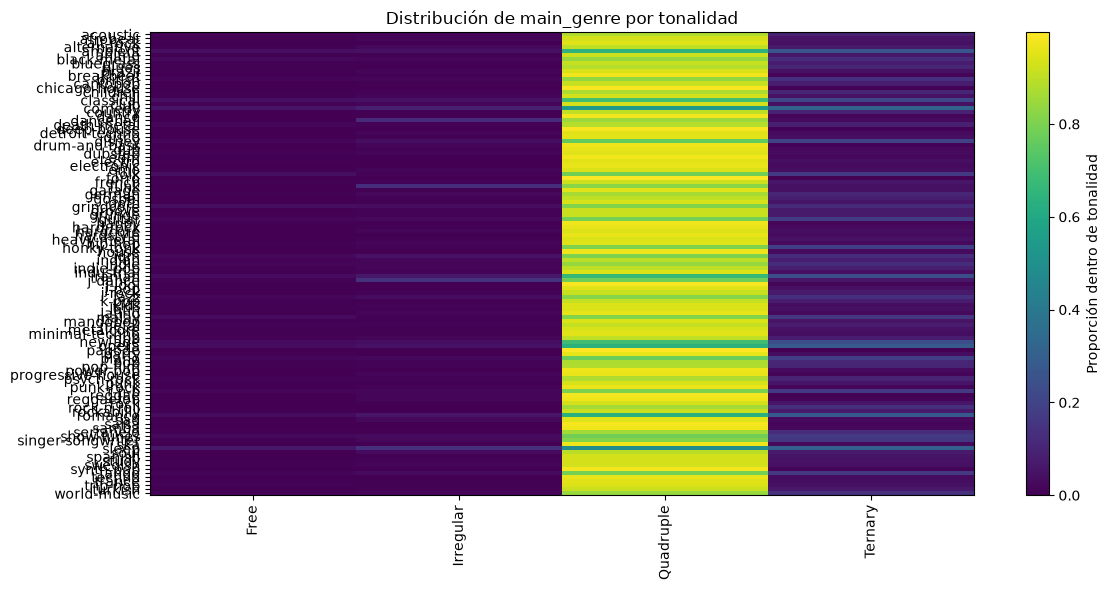

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.imshow(prop_key_genre, aspect="auto")

plt.xticks(
    range(len(prop_key_genre.columns)),
    prop_key_genre.columns,
    rotation=90
)

plt.yticks(
    range(len(prop_key_genre.index)),
    prop_key_genre.index
)

plt.colorbar(label="Proporción dentro de tonalidad")
plt.title("Distribución de main_genre por tonalidad")
plt.tight_layout()
plt.show()